In [43]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [44]:
#Data
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [45]:
data = iris.data
target = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

iris_df = pd.DataFrame(data, columns=feature_names)
iris_df['class'] = target

print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  


In [46]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA()
data_pca = pca.fit_transform(data_scaled)

explained_varience = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_varience)

print("\nExplained Variance Ratio: \n", explained_varience)
print("\n")
print("Cumulative Explained Variance: \n", cumulative_variance)


Explained Variance Ratio: 
 [0.72962445 0.22850762 0.03668922 0.00517871]


Cumulative Explained Variance: 
 [0.72962445 0.95813207 0.99482129 1.        ]


In [48]:
loading_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(4)],
    index=feature_names
)

print(loading_df)

                        PC1       PC2       PC3       PC4
sepal length (cm)  0.521066  0.377418  0.719566 -0.261286
sepal width (cm)  -0.269347  0.923296 -0.244382  0.123510
petal length (cm)  0.580413  0.024492 -0.142126  0.801449
petal width (cm)   0.564857  0.066942 -0.634273 -0.523597


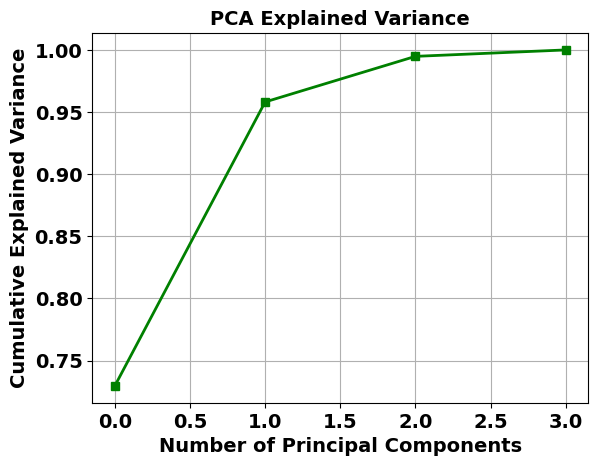

In [49]:
plt.figure()

plt.plot(cumulative_variance, marker='s', linewidth=2, color='green')

##Labels, titles
plt.xlabel("Number of Principal Components", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.title("PCA Explained Variance", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()

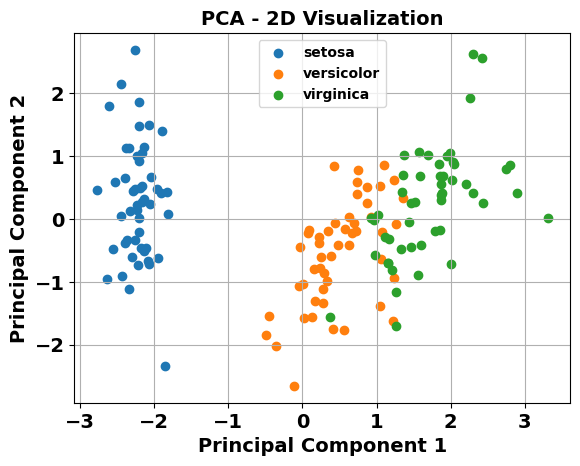

In [50]:
pca_2d = PCA(n_components= 2)
X_pca_2 = pca_2d.fit_transform(data_scaled)

plt.figure()
for i, Target in enumerate(target_names):
  plt.scatter(X_pca_2[target==i, 0], X_pca_2[target==i, 1], label=Target)

##Labels, Titles
plt.xlabel("Principal Component 1", fontsize=14, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=14, fontweight='bold')
plt.title("PCA - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper center')
plt.grid(True)
plt.show()